In [1]:
import numpy as np
import pandas as pd
import random
import copy
import matplotlib.pyplot as plt

In [2]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_hourly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [3]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [4]:
weather.head()

,valid_time,temp,wspd,prcp,pres,week
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18


In [5]:
weather["valid_time"] = pd.to_datetime(weather["valid_time"])
weather["year"] = weather["valid_time"].dt.year
weather["week"] = weather["valid_time"].dt.isocalendar().week.astype(int)
weather["hour"] = weather["valid_time"].dt.hour
weather["honey"] = np.nan
weather["harvest"] = np.nan


In [6]:
last_idx = weather.groupby(["year", "week"])["valid_time"].idxmax()

tmp = weather.loc[last_idx, ["year", "week"]].merge(
    honey,
    on=["year", "week"],
    how="left"
)

weather.loc[last_idx, "honey"] = tmp["honey"].values
weather.loc[last_idx, "harvest"] = tmp["harvest"].values


In [7]:
df = pd.merge(weather, beehives, on="year", how="inner")

In [8]:
df.head()

,valid_time,temp,wspd,prcp,pres,week,year,hour,honey,harvest,beehive
0,2019-05-01 00:00:00,8.404327,3.310282,0.178814,941.63280,18,2019,0,NaN,NaN,92
1,2019-05-01 01:00:00,8.166046,3.494877,0.156403,941.33044,18,2019,1,NaN,NaN,92
2,2019-05-01 02:00:00,7.969513,3.636947,0.191212,941.26220,18,2019,2,NaN,NaN,92
3,2019-05-01 03:00:00,7.678314,3.815005,0.128269,940.87940,18,2019,3,NaN,NaN,92
4,2019-05-01 04:00:00,7.543060,3.679924,0.025272,940.96716,18,2019,4,NaN,NaN,92


Zakładamy, że wydajność pszczółki będzie zależeć od temperatury, prędkości wiatru, ilości opadu atmosferycznego, ciśnienia atmosferycznego oraz jej bazowej wydajności.

In [9]:
# parametry do późniejszej optymalizacji
params = {
    "temp_low": 10,
    "temp_high": 40,

    "wind_penalty": 0.3,

    "rain_penalty": 3.9,

    "pres_penalty": 0.02,
    "pres_ref": 1013.25,

    "base_efficiency": 1.0,

    "daytime_start": 6,   # pszczoły aktywne od tej godziny
    "daytime_end": 20,    # ... do tej godziny (włącznie)
}


In [10]:
def bee_efficiency(temp, wspd, prcp, pres, hour, p):
    """Zwraca efektywność pszczoły [0-1] dla danej godziny."""

    # Poza godzinami dziennej aktywności pszczoły nie latają
    if not (p["daytime_start"] <= hour <= p["daytime_end"]):
        return 0.0

    # Efektywność temperaturowa – liniowy spadek od optymalnego środka zakresu
    temp_mid = (p["temp_low"] + p["temp_high"]) / 2
    temp_range = (p["temp_high"] - p["temp_low"]) / 2
    temp_eff = 1 - abs(temp - temp_mid) / temp_range
    temp_eff = np.clip(temp_eff, 0, 1)

    # Przy silnym wietrze pszczoły nie latają
    wind_eff = 1 - p["wind_penalty"] * wspd
    wind_eff = np.clip(wind_eff, 0, 1)

    # Przy opadach pszczoły nie latają
    rain_eff = 1 - p["rain_penalty"] * prcp
    rain_eff = np.clip(rain_eff, 0, 1)

    # Ciśnienie atmosferyczne – odchylenie od wartości referencyjnej
    pres_eff = 1 - p["pres_penalty"] * abs(pres - p["pres_ref"])
    pres_eff = np.clip(pres_eff, 0, 1)

    eff = (0.45 * temp_eff + 0.20 * wind_eff + 0.25 * rain_eff + 0.10 * pres_eff)
    eff = np.clip(eff, 0, 1)

    return eff


In [11]:
def simulate_honey(row, p):
    """Produkcja miodu dla jednego wiersza (1 godzina)."""

    eff = bee_efficiency(
        row["temp"],
        row["wspd"],
        row["prcp"],
        row["pres"],
        row["hour"],
        p
    )

    honey = (
        row["beehive"] *
        eff *
        p["base_efficiency"]
    )

    return honey


In [12]:
def get_predictions(params_dict, df):
    """Szybka wektorowa predykcja dla całego DataFrame."""
    p = params_dict

    # Maska: godziny dzienne
    daytime = (df["hour"] >= p["daytime_start"]) & (df["hour"] <= p["daytime_end"])

    temp_mid = (p["temp_low"] + p["temp_high"]) / 2
    temp_range = (p["temp_high"] - p["temp_low"]) / 2

    temp_eff = np.clip(1 - np.abs(df["temp"] - temp_mid) / temp_range, 0, 1)
    wind_eff = np.clip(1 - p["wind_penalty"] * df["wspd"], 0, 1)
    rain_eff = np.clip(1 - p["rain_penalty"] * df["prcp"], 0, 1)
    pres_eff = np.clip(1 - p["pres_penalty"] * np.abs(df["pres"] - p["pres_ref"]), 0, 1)

    eff = (0.45 * temp_eff + 0.20 * wind_eff + 0.25 * rain_eff + 0.10 * pres_eff)
    eff = np.clip(eff, 0, 1)
    eff = np.where(daytime, eff, 0.0)

    df = df.copy()
    df["pred"] = df["beehive"] * eff * p["base_efficiency"]

    return df

def to_weekly(df):
    """Agregacja prognoz godzinowych do tygodniowych."""
    weekly_pred = df.groupby(["year", "week"])["pred"].sum().reset_index()
    return weekly_pred

def get_weekly_true(df):
    """Tygodniowe wartości rzeczywiste (zapisane raz na koniec tygodnia)."""
    weekly_true = df[["year", "week", "honey"]].dropna()
    weekly_true = weekly_true.groupby(["year", "week"], as_index=False).first()
    return weekly_true


In [13]:
def loss(params_dict, df):

    # 1. predykcje hourly
    df_pred = get_predictions(params_dict, df)

    # 2. agregacja weekly
    weekly_pred = to_weekly(df_pred)

    # 3. true values
    weekly_true = get_weekly_true(df)

    # 4. merge
    merged = weekly_true.merge(weekly_pred, on=["year", "week"], how="inner")

    # 5. RMSE
    rmse = np.sqrt(np.mean((merged["honey"] - merged["pred"]) ** 2))

    return rmse

In [14]:
# Przykładowe parametry startowe (można użyć jako punkt wyjścia)
bee = {
    "temp_low": 11,
    "temp_high": 31,
    "wind_penalty": 0.25,
    "rain_penalty": 4.2,
    "pres_penalty": 0.015,
    "pres_ref": 1013.25,
    "base_efficiency": 1.05,
    "daytime_start": 6,
    "daytime_end": 20,
}


In [15]:
def fitness(bee_params):
    return loss(bee_params, df)

In [16]:
def random_bee():
    return {
        "temp_low":       random.uniform(5, 12),
        "temp_high":      random.uniform(20, 30),
        "wind_penalty":   random.uniform(0.0, 1.0),
        "rain_penalty":   random.uniform(0.0, 8.0),
        "pres_penalty":   random.uniform(0.0, 0.05),
        "pres_ref":       random.uniform(990, 1030),
        "base_efficiency": random.uniform(0.5, 2.0),
        "daytime_start":  6,
        "daytime_end":    20,
    }

MUTATE_RANGES = {
    "temp_low":        0.5,
    "temp_high":       0.5,
    "wind_penalty":    0.05,
    "rain_penalty":    0.2,
    "pres_penalty":    0.002,
    "pres_ref":        2.0,
    "base_efficiency": 0.05,
}

def mutate(bee):
    new_bee = copy.deepcopy(bee)
    key = random.choice(list(MUTATE_RANGES.keys()))
    delta = MUTATE_RANGES[key]
    new_bee[key] += random.uniform(-delta, delta)
    # temp_low musi być < temp_high
    if new_bee["temp_low"] >= new_bee["temp_high"]:
        new_bee["temp_low"] = new_bee["temp_high"] - 1.0
    return new_bee

population = [random_bee() for _ in range(50)]

def run_opt(iterations=50):
    global population
    for it in range(iterations):
        for i in range(len(population)):
            candidate = mutate(population[i])
            if fitness(candidate) < fitness(population[i]):
                population[i] = candidate
        if (it + 1) % 10 == 0:
            best_rmse = min(fitness(b) for b in population)
            print(f"  Iteracja {it+1}/{iterations}  RMSE={best_rmse:.4f}")
    return min(population, key=fitness)


In [17]:
best_bee = run_opt(iterations=1)
best_rmse = loss(best_bee, df)
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

df['predicted_honey_best'] = df.apply(lambda row: simulate_honey(row, best_bee), axis=1)
df[['year', 'week', 'honey', 'predicted_honey_best']].head(15)

Najlepsze parametry:
{'temp_low': 6.554345319136958, 'temp_high': 20.908906382728702, 'wind_penalty': 0.9774798202796844, 'rain_penalty': 3.6808840115105124, 'pres_penalty': 0.04425762186355671, 'pres_ref': 993.3975450627761, 'base_efficiency': 0.5079778636787484, 'daytime_start': 6, 'daytime_end': 20}
RMSE = 1539.2471


,year,week,honey,predicted_honey_best
0,2019,18,NaN,0.000000
1,2019,18,NaN,0.000000
2,2019,18,NaN,0.000000
3,2019,18,NaN,0.000000
4,2019,18,NaN,0.000000
5,2019,18,NaN,0.000000
6,2019,18,NaN,18.629023
7,2019,18,NaN,23.010610
8,2019,18,NaN,22.939768
9,2019,18,NaN,21.462319


In [18]:
print('Najlepsze parametry:')
print(best_bee)
print(f'RMSE = {best_rmse:.4f}')

Najlepsze parametry:
{'temp_low': 6.554345319136958, 'temp_high': 20.908906382728702, 'wind_penalty': 0.9774798202796844, 'rain_penalty': 3.6808840115105124, 'pres_penalty': 0.04425762186355671, 'pres_ref': 993.3975450627761, 'base_efficiency': 0.5079778636787484, 'daytime_start': 6, 'daytime_end': 20}
RMSE = 1539.2471


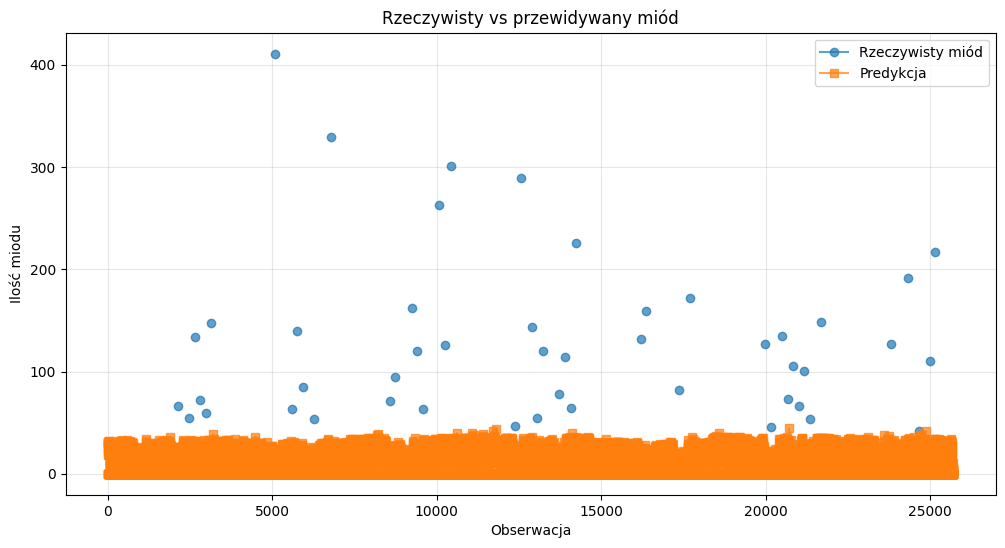

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df["honey"].values, label="Rzeczywisty miód", marker='o', alpha=0.7)
plt.plot(df["predicted_honey_best"].values, label="Predykcja", marker='s', alpha=0.7)
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.xlabel("Obserwacja")
plt.ylabel("Ilość miodu")
plt.grid(True, alpha=0.3)
plt.show()

{'temp_low': 6.338347696149941, 'temp_high': 22.908862499323767, 'temp_slope': 3.8024400255508324, 'wind_penalty': -0.014338742702168422, 'rain_penalty': -0.01074672187225656, 'pres_penalty': -0.013460314012872648, 'base_efficiency': 1.2513008938110284}
RMSE = 78.8268

In [20]:
# najlepszy wynik z run_opt

{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 43.35895073491914, 'wind_penalty': -0.3670792426740751, 'rain_penalty': -1.2448320056154039, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.4877893795676532}
RMSE = 68.1048

In [21]:
{'temp_low': 9.160728007762975, 'temp_high': 24.49404711270679, 'temp_slope': 19.16652515079757, 'wind_penalty': -0.23988570198499704, 'rain_penalty': -1.0159632323437868, 'pres_penalty': -0.00013839921508588746, 'base_efficiency': 0.6871523057723211}
RMSE = 70.3003

In [22]:
# best_params = {
#     'temp_low': 6.338347696149941,
#     'temp_high': 22.908862499323767,
#     'temp_slope': 3.8024400255508324,
#     'wind_penalty': -0.014338742702168422,
#     'rain_penalty': -0.01074672187225656,
#     'pres_penalty': -0.013460314012872648,
#     'base_efficiency': 1.25130089938110284
# }

best_params = {
    'temp_low': 6.419349778306975,
    'temp_high': 19.62405081767822,
    'temp_slope': 3.8882558767525586,
    'wind_penalty': -0.12666327522038567,
    'rain_penalty': -0.11373957615100011,
    'pres_penalty': -0.059464618469573696,
    'base_efficiency': 1.4737018623421179
}



In [23]:
import numpy as np
import pandas as pd

df_results = df.copy()

df_results["prediction"] = df_results.apply(
    lambda row: simulate_honey(row, best_params),
    axis=1
)

df_results["difference"] = df_results["prediction"] - df_results["honey"]
df_results["absolute_error"] = abs(df_results["difference"])

df_results["error_percent"] = (
    df_results["absolute_error"] / df_results["honey"] * 100
)

df_results["accuracy_percent"] = 100 - df_results["error_percent"]
df_results["accuracy_percent"] = df_results["accuracy_percent"].clip(lower=0)

KeyError: 'daytime_start'

In [ ]:
harvest_table = df_results[[
    "year",
    "week",
    "harvest",
    "honey",
    "prediction",
    "difference",
    "absolute_error",
    "error_percent",
    "accuracy_percent"
]].copy()

harvest_table = harvest_table.rename(columns={
    "honey": "actual_honey"
})

harvest_table = harvest_table.round(2)

harvest_table

In [ ]:
yearly_table = (
    df_results
    .groupby("year", as_index=False)
    .agg(
        actual_honey=("honey", "sum"),
        predicted_honey=("prediction", "sum")
    )
)

yearly_table["difference"] = yearly_table["predicted_honey"] - yearly_table["actual_honey"]
yearly_table["absolute_error"] = abs(yearly_table["difference"])

yearly_table["error_percent"] = (
    yearly_table["absolute_error"] / yearly_table["actual_honey"] * 100
)

yearly_table["accuracy_percent"] = 100 - yearly_table["error_percent"]
yearly_table["accuracy_percent"] = yearly_table["accuracy_percent"].clip(lower=0)

yearly_table = yearly_table.round(2)

yearly_table